# Detect crown-of-thorns starfish in underwater image data

Thoughts:

*ML Category:*

Computer Vision: object detection

Predict the presence and position of crown-of-thorns starfish in sequences of underwater images taken at various times and locations around the Great Barrier Reef.


**TODO**: inspect images sampling (does the same fish appear fully, then partially?)


*Input*: images and metadata. An image may contain zero or more starfish.

*Prediction output*: bounding box with a confidence score for each identified starfish.

*Off-line Metrics:*  F2 Score at different intersection over union (IoU) thresholds. The F2 metric weights recall more heavily than precision, as in this case it makes sense to tolerate some false positives in order to ensure very few starfish are missed.

**TODO**:
data preprocessing:
resizing, normalizing, augmenting


**TODO**:
check [the winner](https://www.kaggle.com/competitions/tensorflow-great-barrier-reef/writeups/qns-trust-cv-1st-place-*solution*)


Metadata:

*   video_id - ID number of the video the image was part of. The video ids are not meaningfully ordered.

**TODO**: use embedding layer so it will learn with backprop

*   video_frame - The frame number of the image within the video. Expect to see occasional gaps in the frame number from when the diver surfaced.

**TODO**: use embedding layer so it will learn with backprop

*   sequence - ID of a gap-free subset of a given video. The sequence ids are not meaningfully ordered.

**TODO**: use embedding layer so it will learn with backprop

*   sequence_frame - The frame number within a given sequence.

**TODO**: use embedding layer so it will learn with backprop

*   image_id - ID code for the image, in the format '{video_id}-{video_frame}'

**TODO**: drop it, use it as a key only

*   annotations - The bounding boxes of any starfish detections in a string format that can be evaluated directly with Python. A bounding box is described by the pixel coordinate (x_min, y_min) of its upper left corner within the image together with its width and height in pixels. -
**TODO**: use as Label




## Setup

In [5]:
import pandas as pd
import os, glob, math
import tensorflow as tf

## Load Metadata Data

In [2]:
from google.colab import files
uploaded = files.upload()

In [ ]:
train_set = uploaded['train.csv']

In [ ]:
import io

train_df = pd.read_csv(io.BytesIO(train_set))

In [ ]:
train_df.head()

,video_id,sequence,video_frame,sequence_frame,image_id,annotations
0,0,40258,0,0,0-0,[]
1,0,40258,1,1,0-1,[]
2,0,40258,2,2,0-2,[]
3,0,40258,3,3,0-3,[]
4,0,40258,4,4,0-4,[]


### Images

## EDA

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23501 entries, 0 to 23500
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        23501 non-null  int64 
 1   sequence        23501 non-null  int64 
 2   video_frame     23501 non-null  int64 
 3   sequence_frame  23501 non-null  int64 
 4   image_id        23501 non-null  object
 5   annotations     23501 non-null  object
dtypes: int64(4), object(2)
memory usage: 1.1+ MB


image name: video_{video_id}/{video_frame_number}.jpg

In [ ]:
print(f'# images video 0 = {train_df[train_df['video_id'] == 0]['video_frame'].nunique()}') # 6708 items
print(f'# images video 1 = {train_df[train_df['video_id'] == 1]['video_frame'].nunique()}')
print(f'# images video 2 = {train_df[train_df['video_id'] == 2]['video_frame'].nunique()}')

# images video 0 = 6708
# images video 1 = 8232
# images video 2 = 8561


In [ ]:
sequence0 = train_df[train_df['video_id'] == 0]['sequence']

In [ ]:
print(sequence0.nunique())
print(sequence0.min())
print(sequence0.max())

8
996
59337


<Axes: >

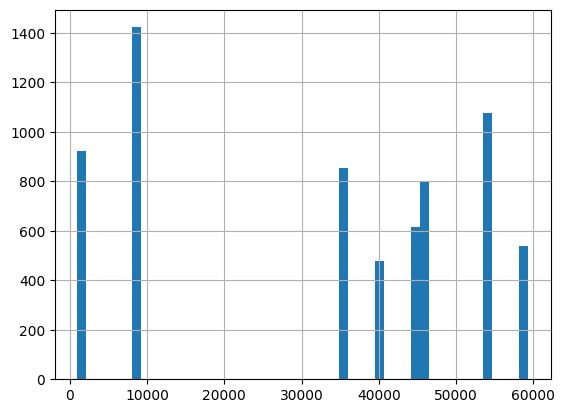

In [ ]:
sequence0.hist(bins = 50)

TODO: use video id and video_frame for retrieving files. use image_id for embedding?

### Label

In [ ]:
train_df[train_df["annotations"] != '[]'].head()

,video_id,sequence,video_frame,sequence_frame,image_id,annotations
16,0,40258,16,16,0-16,"[{'x': 559, 'y': 213, 'width': 50, 'height': 32}]"
17,0,40258,17,17,0-17,"[{'x': 558, 'y': 213, 'width': 50, 'height': 32}]"
18,0,40258,18,18,0-18,"[{'x': 557, 'y': 213, 'width': 50, 'height': 32}]"
19,0,40258,19,19,0-19,"[{'x': 556, 'y': 214, 'width': 50, 'height': 32}]"
20,0,40258,20,20,0-20,"[{'x': 555, 'y': 214, 'width': 50, 'height': 32}]"


In [ ]:
train_df.count()

,0
video_id,23501
sequence,23501
video_frame,23501
sequence_frame,23501
image_id,23501
annotations,23501


## Load image

In [3]:
from google.colab import drive
drive.mount("/content/drive")
# then paths like:
# "/content/drive/MyDrive/reef_images/folder1"

Mounted at /content/drive


In [ ]:
SRC_DIRS = [
    "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/video_0",
    "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/video_1",
    "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/video_2",
]
OUT_DIR = "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords"

os.makedirs(OUT_DIR, exist_ok=True)

In [11]:
# SRC_DIRS = [
#     "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/test0",
#     "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/test1",
# ]
# OUT_DIR = "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/test"


In [12]:
# Write shards

def _bytes_feature(v: bytes) -> tf.train.Feature:
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[v]))

def _int64_feature(v: int) -> tf.train.Feature:
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[v]))

def make_example(img_bytes: bytes, path: str) -> tf.train.Example:
    # Decode once to store height/width (optional but handy)
    img = tf.io.decode_jpeg(img_bytes, channels=3)
    h = int(img.shape[0])
    w = int(img.shape[1])
    feat = {
        "image/encoded": _bytes_feature(img_bytes),
        "image/format": _bytes_feature(b"jpg"),
        "image/height": _int64_feature(h),
        "image/width": _int64_feature(w),
        "image/filename": _bytes_feature(path.encode("utf-8")),
    }
    return tf.train.Example(features=tf.train.Features(feature=feat))

def write_folder_to_tfrecords(src_dir, out_dir, prefix, shard_size=500):

  os.makedirs(out_dir, exist_ok=True)
  files = sorted(glob.glob(os.path.join(src_dir, "*.jpg")))
  num_shards = math.ceil(len(files) / shard_size)
  for shard in range(num_shards):
      start = shard * shard_size
      end = min(len(files), (shard + 1) * shard_size)
      shard_files = files[start:end]

      out_path = os.path.join(out_dir, f"{prefix}-{shard:05d}-of-{num_shards:05d}.tfrecord")
      with tf.io.TFRecordWriter(out_path) as w:
          for p in shard_files:
              img_bytes = tf.io.read_file(p).numpy()
              ex = make_example(img_bytes, p)
              w.write(ex.SerializeToString())

      print("Wrote:", out_path)

write_folder_to_tfrecords(SRC_DIRS[0], OUT_DIR, "video_0")

Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/test/test0-00000-of-00001.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/test/test1-00000-of-00001.tfrecord


In [ ]:
write_folder_to_tfrecords(SRC_DIRS[1], OUT_DIR, "video_1")

Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00000-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00001-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00002-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00003-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00004-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00005-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00006-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_1-00007-of-00017.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_

In [ ]:
write_folder_to_tfrecords(SRC_DIRS[2], OUT_DIR, "video_2")

Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00000-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00001-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00002-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00003-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00004-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00005-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00006-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_2-00007-of-00018.tfrecord
Wrote: /content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/video_

In [21]:
# parse the image
pattern = "/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/reef_tfrecords/*.tfrecord"
ds = tf.data.TFRecordDataset(tf.io.gfile.glob(pattern), num_parallel_reads=tf.data.AUTOTUNE)


In [14]:
# parse the image
def parse(ex):
    spec = {
        "image/encoded": tf.io.FixedLenFeature([], tf.string),
        "image/height": tf.io.FixedLenFeature([], tf.int64),
        "image/width": tf.io.FixedLenFeature([], tf.int64),
        "image/filename": tf.io.FixedLenFeature([], tf.string),
    }
    ex = tf.io.parse_single_example(ex, spec)
    img = tf.io.decode_jpeg(ex["image/encoded"], channels=3)
    return img, ex["image/filename"], ex["image/height"], ex["image/width"]
AUTOTUNE = tf.data.AUTOTUNE
ds = ds.map(parse, num_parallel_calls=AUTOTUNE).batch(16).prefetch(AUTOTUNE)


In [ ]:
ds

<TFRecordDatasetV2 element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>

In [20]:
imgs, names = next(iter(ds))
print(names[:10].numpy())
imgs.shape


[b'/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/test0/0.jpg'
 b'/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/test0/1.jpg'
 b'/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/test0/0.jpg'
 b'/content/drive/MyDrive/Kaggle/tensorflow-great-barrier-reef/train_images/test0/1.jpg']


TensorShape([4, 720, 1280, 3])